# Ligand–receptor scores

Public STAD TPM, first four samples; pancan network, gene symbols. Bulk scores do not demonstrate cell-to-cell communication.

Run from the `tutorials` directory in the prepared iobrx environment. Outputs are written to `extension-work/`; the figure uses a display-only feature z-score. No input values are normalized for the analysis unless the visible API parameters request it.

In [1]:
from pathlib import Path
from time import perf_counter
from contextlib import redirect_stdout, redirect_stderr
import io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iobrx
from _common import load, tpm_input, configure, runtime_info
from _extension_figures import plot_result

iobrx.set_threads(2)
slug = '14_lr_cal'
work = Path("extension-work") / slug
work.mkdir(parents=True, exist_ok=True)
print(json.dumps(runtime_info(), indent=2))
groups = None
configure()


{
  "iobrx": "0.3.0",
  "threads": 2,
  "native_available": true,
  "native_reason": null,
  "sorting": "numpy CPU dispatch",
  "requires_avx512": false,
  "bundled_openblas_found": true,
  "versions": {
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.7.2",
    "iobrpy": "0.2.1",
    "gseapy": "1.3.1",
    "matplotlib": "3.11.1"
  }
}


In [2]:
data = tpm_input().iloc[:, :4]

In [3]:
# Capture upstream progress messages; the computation remains the public API call below.
started = perf_counter()
with warnings.catch_warnings(record=True) as diagnostics, redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    result = iobrx.lr_cal(data, data_type="tpm", id_type="symbol", cancer_type="pancan")
elapsed = perf_counter() - started
for warning in diagnostics:
    print(f"{warning.category.__name__}: {warning.message}")
plot = result.set_index("ID").select_dtypes("number")
tables = result if isinstance(result, dict) else {"result": result}
for name, table in tables.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(work / (name + ".csv"))
plot.to_csv(work / "display_source.csv")
timing = {"analysis": slug, "input_shape": list(data.shape), "seconds": elapsed, "threads": 2, "scope": "one API call; excludes input preparation", "fixture": 'Public STAD TPM, first four samples; pancan network, gene symbols. Bulk scores do not demonstrate cell-to-cell communication.'}
Path("results").mkdir(exist_ok=True)
Path("results", slug + "_timing.json").write_text(json.dumps(timing, indent=2) + "\n")
print(json.dumps(timing, indent=2))
display(plot.head())

{
  "analysis": "14_lr_cal",
  "input_shape": [
    48058,
    4
  ],
  "seconds": 0.14339405001373962,
  "threads": 2,
  "scope": "one API call; excludes input preparation",
  "fixture": "Public STAD TPM, first four samples; pancan network, gene symbols. Bulk scores do not demonstrate cell-to-cell communication."
}


,A2M_APP_CALR_LRPAP1_PSAP_SERPING1_LRP1,ADAM10_AXL,ADAM10_EFNA1_EPHA3,ADAM12_ITGA9,ADAM12_ITGB1_SDC4,ADAM15_ITGA5,ADAM15_FN1_ITGA9,ADAM15_ITGAV,ADAM15_ITGB1,ADAM15_COL1A2_FN1_MFGE8_ITGB3,...,WNT5A_FZD6,WNT5A_LRP5,WNT5A_MCAM,WNT5A_ROR1,WNT5A_ROR2,WNT5A_RYK,WNT7A_FZD5,WNT7B_FZD1,WNT7B_LRP5,ZP3_MERTK
ID,,,,,,,,,,,,,,,,,,,,,
TCGA-BR-6455,5.998810,4.272555,2.567951,2.697825,2.697825,5.162837,3.669981,5.052006,6.098248,1.084239,...,2.508899,2.508899,2.508899,2.508899,2.508899,2.508899,0.070764,0.662351,0.662351,2.972408
TCGA-BR-7196,6.683444,4.370891,3.298835,2.380055,2.380055,6.207330,4.951296,5.225227,6.328787,1.791130,...,3.473818,3.473818,3.473818,3.473818,3.473818,3.473818,0.040705,0.194806,0.194806,1.842344
TCGA-BR-8371,5.746699,3.241281,2.532504,0.956855,0.956855,5.277485,5.277485,4.131683,5.277485,2.225894,...,2.066661,2.066661,2.066661,2.066661,2.066661,2.066661,0.049771,0.972519,0.972519,0.838352
TCGA-BR-8380,7.267795,4.131655,3.661524,2.592163,2.592163,5.985582,5.985582,5.216775,5.985582,3.326857,...,3.475834,3.475834,3.475834,3.475834,3.475834,3.475834,0.039375,0.878682,0.878682,2.422196


findfont: Failed to find font weight medium, now using 400.


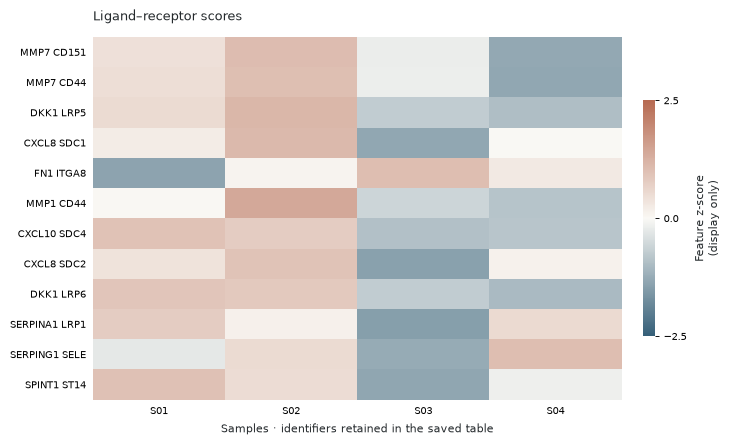

In [4]:
configure(2)
fig = plot_result(plot, 'Ligand–receptor scores', 2, groups=groups)
for extension in ('png', 'pdf', 'svg'):
    fig.savefig(Path('figures') / (slug + '.' + extension), dpi=200, bbox_inches='tight')
review = Path('review/extensions')
review.mkdir(parents=True, exist_ok=True)
fig.savefig(review / (slug + '-round-2.png'), dpi=120, bbox_inches='tight')
plt.show()

Interpretation: the heatmap highlights relative patterns within each displayed feature. Colors are not cell fractions, statistical significance or cross-feature effect sizes. Full numeric outputs are saved separately. Runtime depends on hardware, input size, parameters and cache state.